1. IMPORTS

In [2]:
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt



2. LOAD AND CLEAN DATA

In [3]:
df= pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
df.head()
df=df.drop_duplicates()
df.shape

df = df.fillna(df.mean(numeric_only=True))


df = df[df['DPOR'] >= 0]     
df = df[df['CNLS'] >= 0]     
df = df[df['RHOB'] > 0]     

print("Data shape after cleaning:", df.shape)



Data shape after cleaning: (8682, 14)


3. FEATURE SELECTION

In [4]:
X = df[['Depth','GR','RILD','DPOR','RHOB','SP']]
#depth , GR= gamma ray, RILD = Induction log (resistivity),DPOR =Density Porosity , RHOB= Bulk Density , SP= Sponatneous Potential

import numpy as np

gr_low   = df['GR'].quantile(0.40)     # sand tendency
gr_high  = df['GR'].quantile(0.70)     # shale tendency

res_high = df['RILD'].quantile(0.70)   # high resistivity
res_low  = df['RILD'].quantile(0.30)   # low resistivity

por_high = df['DPOR'].quantile(0.60)   # good porosity
por_low  = df['DPOR'].quantile(0.30)   # poor porosity

den_low  = df['RHOB'].quantile(0.35)   # lighter rock (sand)
den_high = df['RHOB'].quantile(0.75)   # denser rock (shale)

sp_str   = df['SP'].abs().quantile(0.60)  # strong SP deflection


df['sand_score'] = 0


df.loc[df['GR']   < gr_low,   'sand_score'] += 1
df.loc[df['RILD'] > res_high,'sand_score'] += 1
df.loc[df['DPOR'] > por_high,'sand_score'] += 1
df.loc[df['RHOB'] < den_low, 'sand_score'] += 1
df.loc[df['SP'].abs() > sp_str, 'sand_score'] += 1



df.loc[df['GR']   > gr_high,  'sand_score'] -= 1
df.loc[df['RILD'] < res_low, 'sand_score'] -= 1
df.loc[df['DPOR'] < por_low, 'sand_score'] -= 1
df.loc[df['RHOB'] > den_high,'sand_score'] -= 1
df.loc[(df['SP'].abs() < sp_str) & (df['GR'] > gr_high), 'sand_score'] -= 1


df['Facies'] = np.where(df['sand_score'] >= 2,
                        'Sandstone',
                        'Shale')



print(df['Facies'].value_counts())

Facies
Shale        5834
Sandstone    2848
Name: count, dtype: int64


4. ENCODING LABELS

In [7]:
X = df[['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']]


y = df['Facies']

le = LabelEncoder()
y = le.fit_transform(y)
# Sandstone -> 0, Shale -> 1





5. TRAIN - TEST SPLIT

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

6. SCALING

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


7. TRAIN RANDOM FOREST

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)
import joblib
joblib.dump(rf, "rf_model.pkl")


['rf_model.pkl']

8. ACCURACY AND CLASSIFICATION

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


Random Forest Accuracy : 0.9961612284069098

Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       855
           1       1.00      1.00      1.00      1750

    accuracy                           1.00      2605
   macro avg       1.00      1.00      1.00      2605
weighted avg       1.00      1.00      1.00      2605



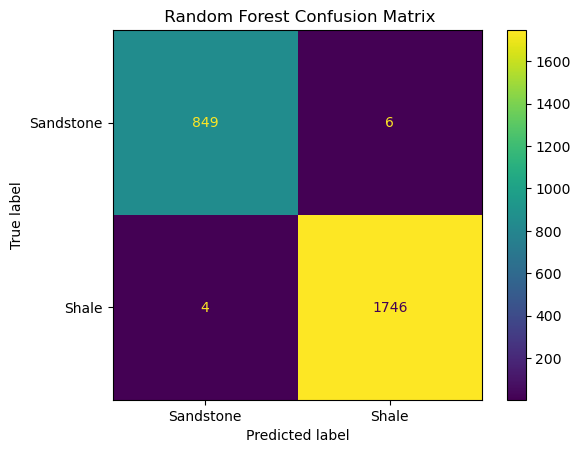

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Sandstone","Shale"])
disp.plot()
plt.title(" Random Forest Confusion Matrix")
plt.show()


9. SAVING MODEL
   

In [18]:
folder_path = os.path.abspath("saved_models")
os.makedirs(folder_path, exist_ok=True)

rf_path = os.path.join(folder_path, "rf.pkl")
le_path = os.path.join(folder_path, "label_encoder.pkl")

joblib.dump(rf, rf_path)
joblib.dump(le, le_path)

print("Random Forest model saved successfully.")



Random Forest model saved successfully.


In [ ]:
df['Model'] = 'Random Forest'
df.to_csv('rf_output.csv', index=False)